In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Exploration of CLIP flaws

Multimodal model can have unexpected biases. CLIP, for example, is strongly biased toward text in the text. A great example can be found [here](https://arxiv.org/pdf/2508.05430#page=8.94), Figure 6, where CLIP "sees" a doll, but is actually focused on "dollar" text, not an actual doll. Is thid a **real** problem? Considering that most of the content on web is watermarked in some way, this might be an issue. During today's lab, we will try to reproduce this phenomena on ImageNet creating artifically injected watermarks.

The coding agenda is as follow:

1. load a CLIP and stream ImageNet dataset
2. create a custom version of dataset with injected watermarks
3. iterate over dataset, compute metrics on original and injected data
4. compute simple CAV (diff means)
5. debias representation of injected data and compare metric to the original data

In [22]:
import os
import numpy as np
from PIL import ImageFont, ImageDraw, Image as PILImage

### 00 Prelimaries

code below serves as utilty to inject watermarks. You need to pass `image` and `text` to be injected, the rest of parameters can be left as default. The watermark transformation can be used via

```python
torchvision.transforms.Compose([partial(add_watermark, ...), clip_text_preprocessor])
```

In [23]:
_IMAGE_SIZE_TO_FONT_SIZE = {
    224: 36,
    384: 62,
    512: 82,
    518: 84,
}
_FONT_SIZE_RATIO = 6.22


def add_watermark(
    image: np.ndarray | PILImage.Image,
    image_size: int = 224,
    text: str = "TEXT",
    font_path: str = "SourceHanSerifSC-ExtraLight.otf",
    opacity: float = 0.5,
    color: tuple[int, int, int] = (255, 255, 255),
    x_pos: float = 0.1,
    y_pos: float = 0.4,
) -> PILImage.Image:
    """
    Add semi-transparent text watermark overlay to an image.

    The watermark is composited using alpha blending, preserving the original
    image with the text rendered on top at the specified opacity.

    Args:
        image: Input PIL Image or numpy array to add watermark to
        image_size: Size of input image in pixels, used for font size calculation (default: 224)
        text: Watermark text to overlay (default: WATERMARK_TEXT)
        font_path: Path to TrueType/OpenType font file (default: SourceHanSerifSC-ExtraLight.otf)
        opacity: Watermark opacity in range [0.0, 1.0] where 0.0 is fully transparent
            and 1.0 is fully opaque (default: 0.5)
        color: RGB color tuple for watermark text (default: (255, 255, 255) white)
        x_pos: Horizontal position as fraction of image width in range [0.0, 1.0] (default: 0.01)
        y_pos: Vertical position as fraction of image height in range [0.0, 1.0] (default: 0.4)

    Returns:
        PIL Image with watermark overlay applied, converted to RGB mode

    Raises:
        FileNotFoundError: If font_path doesn't exist
        ValueError: If opacity, x_pos, or y_pos are outside the valid range [0.0, 1.0]
    """
    # Validate font path
    if not os.path.exists(font_path):
        raise FileNotFoundError(f"Font file not found: {font_path}")

    # Validate range parameters
    if not 0.0 <= opacity <= 1.0:
        raise ValueError(f"Opacity must be in range [0.0, 1.0], got {opacity}")
    if not 0.0 <= x_pos <= 1.0:
        raise ValueError(f"x_pos must be in range [0.0, 1.0], got {x_pos}")
    if not 0.0 <= y_pos <= 1.0:
        raise ValueError(f"y_pos must be in range [0.0, 1.0], got {y_pos}")

    # Calculate appropriate font size
    if image_size in _IMAGE_SIZE_TO_FONT_SIZE:
        font_size = _IMAGE_SIZE_TO_FONT_SIZE[image_size]
    else:
        font_size = int(image_size / _FONT_SIZE_RATIO)

    font = ImageFont.truetype(font_path, font_size)

    # If np.array convert to PIL
    if isinstance(image, np.ndarray):
        image = PILImage.fromarray(image.astype(np.uint8), 'RGB')

    # Convert to RGBA for alpha compositing
    image_rgba = image.convert("RGBA")
    width, height = image_rgba.size

    # Create transparent overlay for watermark text
    watermark_layer = PILImage.new("RGBA", image_rgba.size, (255, 255, 255, 0))
    draw = ImageDraw.Draw(watermark_layer)

    # Draw text with specified opacity
    draw.text(
        xy=(x_pos * width, y_pos * height),
        text=text,
        fill=(*color, round(opacity * 255)),  # Cleaner tuple unpacking
        font=font,
    )

    # Composite watermark onto image and convert back to RGB
    output_img = PILImage.alpha_composite(image_rgba, watermark_layer).convert("RGB")
    return output_img

### 01 CLIP and Imagenet loading

You should already know how to load CLIP from previous labs. For ImageNet, you need to find it on HuggingFace. You can check for `imagenet-1k` for smaller volume. Note that "mini" version is still too bug to make the full experiment, so feel free to constraint experiments to 100-200 images. Use `streaming=True`, so the datasrt is not donwloaded on your PC/notebook, but is streamed from web. It is much slower, but fits our needs best.

Side note: `test` split of ImageNet does not have labels.

In [24]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
from datasets import load_dataset

model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
from huggingface_hub import login
login()

In [26]:
dataset = load_dataset("imagenet-1k", split="validation", streaming=True, trust_remote_code=True)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'imagenet-1k' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'imagenet-1k' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

In [27]:
class_names = dataset.features["label"].names
texts = [f"a photo of a {name}" for name in class_names]

### 02 Custom dataset

Because of `streaming=True`, you already have `IterableDatset` object. It already has `__getitem__` implemented, so we need to add our custom logic in `__iter__`. The logic should be as follows:

```python
    def __iter__(self):
        for example in self.dataset:
            <your code here>
            yield img, img_corrupted, label
```

Remember that `yield` should return `Tensor`, `dict[str, Tensor]`, or so. Ensure that your custom dataset returns (original image after CLIP processing, image after watermark injection and CLIP processing, original label).

Tip: datasets typically returns index of a class, not its label (e.g., `1`, not `goldfish`). You can still find label using `dataset.features["label"].int2str(IDX)`.

Tip 2: because of streaming, the biggest bottleneck is HuggingFace API, consider setting `batch_size` on `64` or more.

In [28]:
from torch.utils.data import IterableDataset, DataLoader
import itertools


In [29]:
class WatermarkedImageNet(IterableDataset):
    def __init__(self, dataset, processor, watermark_text, limit=200):
        self.dataset = dataset
        self.processor = processor
        self.watermark_text = watermark_text
        self.limit = limit

    def __iter__(self):
            limited_dataset = itertools.islice(self.dataset, self.limit)

            for example in limited_dataset:
                raw_image = example["image"]
                label_idx = example["label"]

                if raw_image.mode != "RGB":
                    raw_image = raw_image.convert("RGB")

                label_str = self.dataset.features["label"].int2str(label_idx)

                img_corrupted = add_watermark(raw_image, text=self.watermark_text)

                img_tensor = self.processor(images=raw_image, return_tensors="pt")["pixel_values"].squeeze(0)
                img_corrupted_tensor = self.processor(images=img_corrupted, return_tensors="pt")["pixel_values"].squeeze(0)

                yield img_tensor, img_corrupted_tensor, label_str

In [30]:
custom_dataset = WatermarkedImageNet(dataset, processor, watermark_text="BLUEBERRY", limit=256)
dataloader = DataLoader(custom_dataset, batch_size=64)

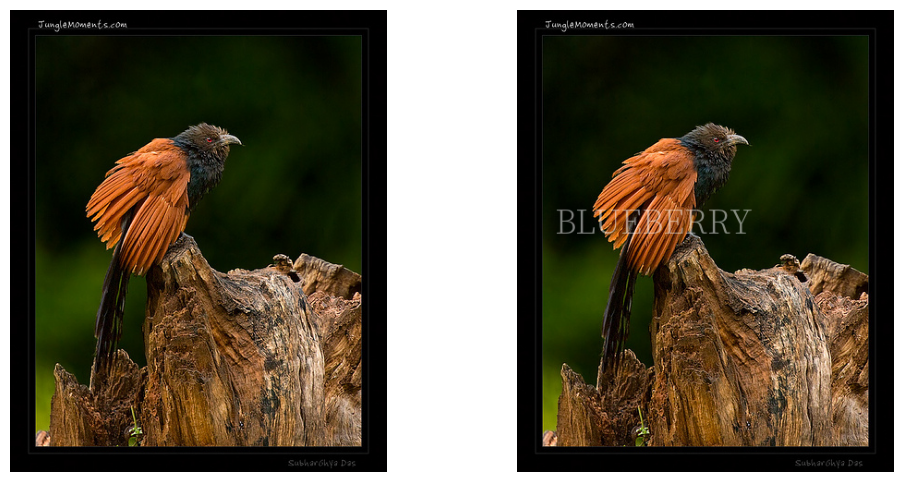

In [31]:
import matplotlib.pyplot as plt

example = next(iter(dataset))

original_image = example["image"].convert("RGB")
label_name = dataset.features["label"].int2str(example["label"])

watermarked_image = add_watermark(original_image, text="BLUEBERRY")

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(original_image)
axs[0].axis('off')

axs[1].imshow(watermarked_image)
axs[1].axis('off')

plt.show()

### 03 Metrics computation

So far, you should have loaded CLIP and iterable dataset. Now it's time to creating **interesting** experiment. The design is up to you, but let's check my proposal below:

> - set watermark text to something like "BLUEBERRY"
> - use CLIP in zero-shot mode (comparing embedding of text and image)
> - check how many images will be predicted as "BLUEBERRY" rather than the original class
>   - e.g., compare cossim(image_watermark, "a photo of a BLUEBERRY") and cossim(image_watermark, "a photo of [ORIGINAL CLASS]")

After this step, you should tell the accuracy of the CLIP in distinguishing between BLUEBERRY and [ORIGINAL CLASS] on original data and data with watermarks (or analogous metrics in our own experiment design).

Tip: use `padding=True` when processing text in batches.

Note: I proposed BLUEBERRY for no particural reason, but keep in mind tht ImageNet contains ~all types of images so to be completly fair in this experiment we should choose something that does not occur in this dataset probably.

In [32]:
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

bb_text = "a photo of a BLUEBERRY"
bb_inputs = processor(text=[bb_text], return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    bb_outputs = model.text_model(**bb_inputs)
    bb_features = model.text_projection(bb_outputs.pooler_output)
    bb_features = F.normalize(bb_features, dim=-1)

orig_correct = 0
corr_correct = 0
total_samples = 0
limit_batches = 4

with torch.no_grad():
    for i, (img, img_corrupted, labels) in enumerate(dataloader):
        if i >= limit_batches:
            break

        img = img.to(device)
        img_corrupted = img_corrupted.to(device)

        # Teksty oryginalnych klas
        orig_texts = [f"a photo of a {label}" for label in labels]
        text_inputs = processor(text=orig_texts, return_tensors="pt", padding=True).to(device)

        # Obliczenie cech tekstowych
        text_outputs = model.text_model(**text_inputs)
        text_features = model.text_projection(text_outputs.pooler_output)
        text_features = F.normalize(text_features, dim=-1)

        # Obliczenie cech obrazów oryginalnych
        img_outputs = model.vision_model(pixel_values=img)
        img_features = model.visual_projection(img_outputs.pooler_output)
        img_features = F.normalize(img_features, dim=-1)

        # Obliczenie cech obrazów ze znakiem wodnym
        img_corr_outputs = model.vision_model(pixel_values=img_corrupted)
        img_corr_features = model.visual_projection(img_corr_outputs.pooler_output)
        img_corr_features = F.normalize(img_corr_features, dim=-1)

        # Podobieństwo cosinusowe
        sim_orig_true = (img_features * text_features).sum(dim=-1)
        sim_corr_true = (img_corr_features * text_features).sum(dim=-1)

        sim_orig_bb = (img_features * bb_features).sum(dim=-1)
        sim_corr_bb = (img_corr_features * bb_features).sum(dim=-1)

        #Sprawdzanie trafień
        orig_correct += (sim_orig_true > sim_orig_bb).sum().item()
        corr_correct += (sim_corr_true > sim_corr_bb).sum().item()
        total_samples += img.size(0)


print(f"Przetestowano obrazów: {total_samples}")
print(f"Skuteczność na CZYSTYCH obrazach: {orig_correct / total_samples * 100:.2f}%")
print(f"Skuteczność na ZEPSUTYCH obrazach: {corr_correct / total_samples * 100:.2f}%")

wrong_hits = (total_samples - corr_correct) / total_samples * 100
print(f"\n CLIP uznał {wrong_hits:.2f}% zepsutych obrazów za BLUEBERRY")

'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/imagenet-1k/resolve/49e2ee26f3810fb5a7536bbf732a7b07389a47b5/data/validation-00000-of-00014.parquet
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/imagenet-1k/resolve/49e2ee26f3810fb5a7536bbf732a7b07389a47b5/data/validation-00000-of-00014.parquet
Retrying in 1s [Retry 1/5].


Przetestowano obrazów: 256
Skuteczność na CZYSTYCH obrazach: 100.00%
Skuteczność na ZEPSUTYCH obrazach: 96.88%

 CLIP uznał 3.12% zepsutych obrazów za BLUEBERRY


### 04 CAV computation

In this step, you should create a CAV (e.g., DiffMeans we used in previous work) and check its detection power - i.e., `rocauc(cossim(CAV, data))`. This should be really easy!

In [33]:
from sklearn.metrics import roc_auc_score

all_img_features = []
all_corr_features = []

with torch.no_grad():
    for i, (img, img_corrupted, labels) in enumerate(dataloader):
        if i >= limit_batches:
            break

        img = img.to(device)
        img_corrupted = img_corrupted.to(device)

        # Embeddingi czystych obrazów
        img_outputs = model.vision_model(pixel_values=img)
        img_features = model.visual_projection(img_outputs.pooler_output)
        img_features = F.normalize(img_features, dim=-1)

        # Embeddingi zepsutych obrazów
        img_corr_outputs = model.vision_model(pixel_values=img_corrupted)
        img_corr_features = model.visual_projection(img_corr_outputs.pooler_output)
        img_corr_features = F.normalize(img_corr_features, dim=-1)

        all_img_features.append(img_features.cpu())
        all_corr_features.append(img_corr_features.cpu())

all_img_features = torch.cat(all_img_features, dim=0)
all_corr_features = torch.cat(all_corr_features, dim=0)

# DiffMeans:
mean_clean = all_img_features.mean(dim=0)
mean_corr  = all_corr_features.mean(dim=0)

cav = mean_corr - mean_clean
cav = F.normalize(cav.unsqueeze(0), dim=-1).squeeze(0)



#  Moc detekcji przez ROCAUC
all_embeds = torch.cat([all_img_features, all_corr_features], dim=0)
binary_labels = torch.cat([
    torch.zeros(len(all_img_features)),
    torch.ones(len(all_corr_features)),
])

scores = (all_embeds @ cav).numpy()

auc = roc_auc_score(binary_labels.numpy(), scores)

print(f"ROCAUC: {auc:.4f}")

ROCAUC: 0.9286


### 05 Debiasing

Now we have everything we need to make CLIP robust to watermarks. In this step, repeat the logic from **03**, but make an ortogonalisation of data with injected watermark. Ideally, its CLIP's embedding should be similar to the original data (you can check!); however, our main goal is to just improve the accuracy of zero-shot classification.

In [34]:
def orthogonalise(embeddings: torch.Tensor, cav: torch.Tensor) -> torch.Tensor:
    """Usuwa składową CAV z każdego embeddingu i re-normalizuje."""
    proj = (embeddings @ cav).unsqueeze(1) * cav.unsqueeze(0)
    debiased = embeddings - proj
    return F.normalize(debiased, dim=-1)

all_corr_debiased = orthogonalise(all_corr_features, cav)

# Czy po debiasingu embeddingi zepsute są bliżej oryginalnych?
cos_przed = (all_img_features * all_corr_features).sum(dim=-1)
cos_po    = (all_img_features * all_corr_debiased).sum(dim=-1)

print("Podobieństwo cosinusowe zepsutych do czystych:")
print(f"  Przed debiasingiem: {cos_przed.mean().item():.4f} ± {cos_przed.std().item():.4f}")
print(f"  Po debiasingu:      {cos_po.mean().item():.4f} ± {cos_po.std().item():.4f}")

# Znowu klasyfikacja
orig_correct_d = 0
corr_correct_d = 0

bb_cav = cav.to(device)
bb_features_cpu = bb_features.cpu()

with torch.no_grad():
    for i, (img, img_corrupted, labels) in enumerate(dataloader):
        if i >= limit_batches:
            break

        img = img.to(device)

        # Embeddingi czystych obrazów
        img_outputs = model.vision_model(pixel_values=img)
        img_feat = model.visual_projection(img_outputs.pooler_output)
        img_feat = F.normalize(img_feat, dim=-1).cpu()

        # Embeddingi zepsutych i ortogonalizacja
        img_corrupted = img_corrupted.to(device)
        img_corr_outputs = model.vision_model(pixel_values=img_corrupted)
        img_corr_feat = model.visual_projection(img_corr_outputs.pooler_output)
        img_corr_feat = F.normalize(img_corr_feat, dim=-1).cpu()
        img_corr_feat = orthogonalise(img_corr_feat, cav.cpu())

        orig_texts = [f"a photo of a {label}" for label in labels]
        text_inputs = processor(text=orig_texts, return_tensors="pt", padding=True)
        text_outputs = model.text_model(**text_inputs)
        text_feat = model.text_projection(text_outputs.pooler_output)
        text_feat = F.normalize(text_feat, dim=-1).cpu()

        sim_clean_true = (img_feat * text_feat).sum(dim=-1)
        sim_clean_bb   = (img_feat * bb_features_cpu).sum(dim=-1)

        sim_corr_true  = (img_corr_feat * text_feat).sum(dim=-1)
        sim_corr_bb    = (img_corr_feat * bb_features_cpu).sum(dim=-1)

        orig_correct_d += (sim_clean_true > sim_clean_bb).sum().item()
        corr_correct_d += (sim_corr_true  > sim_corr_bb).sum().item()

print(f"\n--- WYNIKI PO DEBIASINGU ---")
print(f"Skuteczność na CZYSTYCH obrazach:            {orig_correct_d / total_samples * 100:.2f}%")
print(f"Skuteczność na ZEPSUTYCH (przed debiasngiem): {corr_correct / total_samples * 100:.2f}%")
print(f"Skuteczność na ZEPSUTYCH (po debiasingu):    {corr_correct_d / total_samples * 100:.2f}%")
print(f"\nPoprawa accuracy: {(corr_correct_d - corr_correct) / total_samples * 100:+.2f} pp")


Podobieństwo cosinusowe zepsutych do czystych:
  Przed debiasingiem: 0.9347 ± 0.0390
  Po debiasingu:      0.9556 ± 0.0233

--- WYNIKI PO DEBIASINGU ---
Skuteczność na CZYSTYCH obrazach:            100.00%
Skuteczność na ZEPSUTYCH (przed debiasngiem): 96.88%
Skuteczność na ZEPSUTYCH (po debiasingu):    98.83%

Poprawa accuracy: +1.95 pp
